# 01 - Exploratory Data Analysis
**Analysis of the Physiological Effects of Spaceflight**

This notebook explores both datasets:
1. `astronauts_clean.csv` — 570 real astronauts, career flight stats
2. `physiological_effects.csv` — 38 literature-sourced physiological findings

Goal: understand the shape of the data, spot early patterns, and validate what will feed the dashboard.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_colwidth', 60)

astro = pd.read_csv('../data/processed/astronauts_clean.csv')
physio = pd.read_csv('../data/raw/physiological_effects.csv')

print('Astronauts:', astro.shape)
print('Physiological findings:', physio.shape)

Astronauts: (570, 8)
Physiological findings: (38, 14)


## 1. Astronaut Dataset Overview

In [2]:
astro.head()

,name,country,gender,num_flights,parsed_flight_count,total_flight_days,duration_category,flights_raw
0,Gennady Padalka,Russia,Man,5,5,878.48,Long (90+ days total),"Soyuz TM-28 (1998), Soyuz TMA-4 (2004), Soyuz TMA-14 (20..."
1,Yuri Malenchenko,Russia,Man,6,6,826.39,Long (90+ days total),"Soyuz TM-19 (1994), STS-106 (2000), Soyuz TMA-2 (2003), ..."
2,Sergei Krikalev,Russia,Man,6,6,803.40,Long (90+ days total),"Soyuz TM-7 (1988), Soyuz TM-12 (1991), STS-60 (1994), ST..."
3,Alexander Kaleri,Russia,Man,5,5,769.27,Long (90+ days total),"Soyuz TM-14 (1992), Soyuz TM-24 (1996), Soyuz TM-30 (200..."
4,Oleg Kononenko,Russia,Man,4,4,736.78,Long (90+ days total),"Soyuz TMA-12 (2008), Soyuz TMA-03M (2011), Soyuz TMA-17M..."


In [3]:
astro['duration_category'].value_counts()

duration_category
Medium (14-90 days total)    234
Long (90+ days total)        171
Short (<14 days total)       165
Name: count, dtype: int64

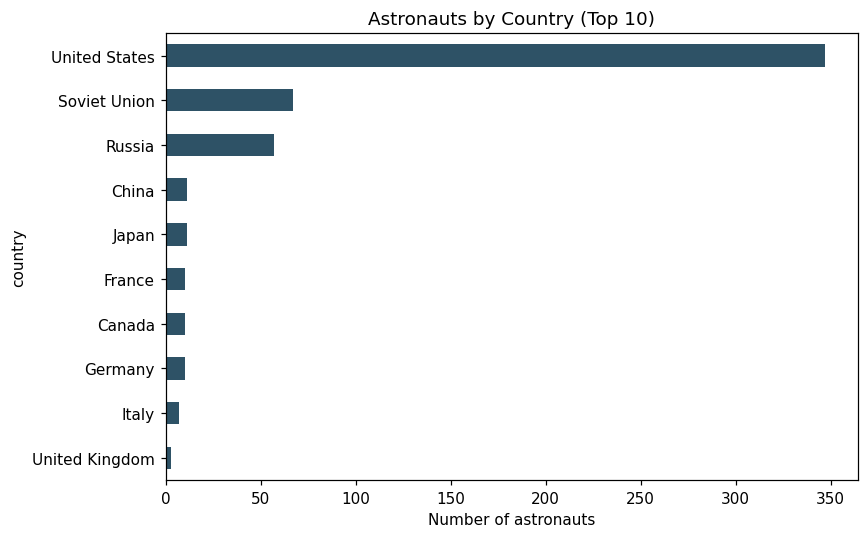

In [4]:
fig, ax = plt.subplots(figsize=(8,5))
astro['country'].value_counts().head(10).sort_values().plot(kind='barh', ax=ax, color='#2E5266')
ax.set_xlabel('Number of astronauts')
ax.set_title('Astronauts by Country (Top 10)')
plt.tight_layout()
plt.savefig('../reports/figures/01_astronauts_by_country.png')
plt.show()

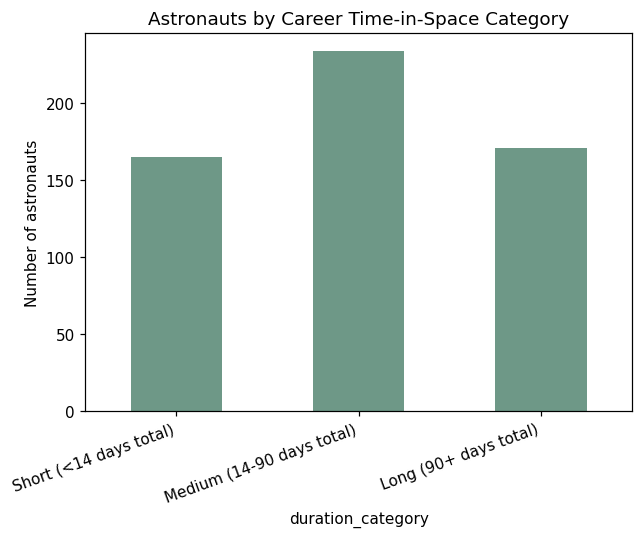

In [5]:
order = ['Short (<14 days total)', 'Medium (14-90 days total)', 'Long (90+ days total)']
fig, ax = plt.subplots(figsize=(6,5))
astro['duration_category'].value_counts().reindex(order).plot(kind='bar', ax=ax, color='#6E9887')
ax.set_ylabel('Number of astronauts')
ax.set_title('Astronauts by Career Time-in-Space Category')
ax.set_xticklabels(order, rotation=20, ha='right')
plt.tight_layout()
plt.savefig('../reports/figures/02_astronauts_duration_category.png')
plt.show()

**Observation**: US and Soviet/Russian programs dominate the dataset (long ISS/Shuttle/Mir/Soyuz history). Career time-in-space is fairly evenly spread across Short/Medium/Long — good for later filtering in the dashboard.

## 2. Physiological Effects Dataset Overview

In [6]:
physio.head()

,record_id,system,measure,body_site_or_context,mission_duration_category,duration_days_approx,metric_type,value,value_low,value_high,unit,measurement_method,source_citation,source_url
0,B001,Bone,Bone mineral density change,Femoral neck,Long,180.0,percent_change_per_month,-1.00,NaN,NaN,%/month,DXA,NASA HHP Bone and Mineral Lab review,https://www.nasa.gov/directorates/esdmd/hhp/bone-and-min...
1,B002,Bone,Bone mineral density change,Proximal femur (hip),Long,180.0,percent_change_per_month,-1.25,-1.0,-1.5,%/month,DXA,NASA HHP Bone and Mineral Lab review,https://www.nasa.gov/directorates/esdmd/hhp/bone-and-min...
2,B003,Bone,Bone mineral density change,Lumbar spine,Long,180.0,percent_change_per_month,-1.30,-1.0,-1.6,%/month,DXA,NASA HHP Bone and Mineral Lab review,https://www.nasa.gov/directorates/esdmd/hhp/bone-and-min...
3,B004,Bone,Total bone density change (region),Skull,Long,180.0,percent_change_total,2.20,1.1,3.3,%,DXA/CT meta-analysis,Systematic review & meta-analysis of bone loss in space ...,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7200725
4,B005,Bone,Total bone density change (region),Thorax and upper limbs,Long,180.0,percent_change_total,-1.40,-2.1,-0.6,%,DXA/CT meta-analysis,Systematic review & meta-analysis of bone loss in space ...,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7200725


In [7]:
physio.groupby(['system','metric_type'])['value'].agg(['count','mean','min','max'])

count       mean    min    max
system         metric_type                                                 
Bone           percent_change_per_month          3  -1.183333  -1.30  -1.00
               percent_change_total              5  -2.780000  -6.20   2.20
               percent_recovered_astronauts      2  40.400000  34.00  46.80
Cardiovascular incidence_percent                 3  46.000000  25.00  83.00
               mean_change_ml                    1  -5.370000  -5.37  -5.37
               percent_change_total              4  11.000000 -13.50  40.50
Muscle         percent_change_total             10 -12.730000 -27.50  -3.90
Sleep          incidence_percent                 2  45.450000  43.80  47.10
               mean_hours                        8   6.742500   5.40   8.50

**Important**: different rows use different `metric_type`s (percent change, hours, incidence %). Never average across metric types blindly — always group by `metric_type` first, as done above.

## 3. Bone: % Change by Skeletal Site

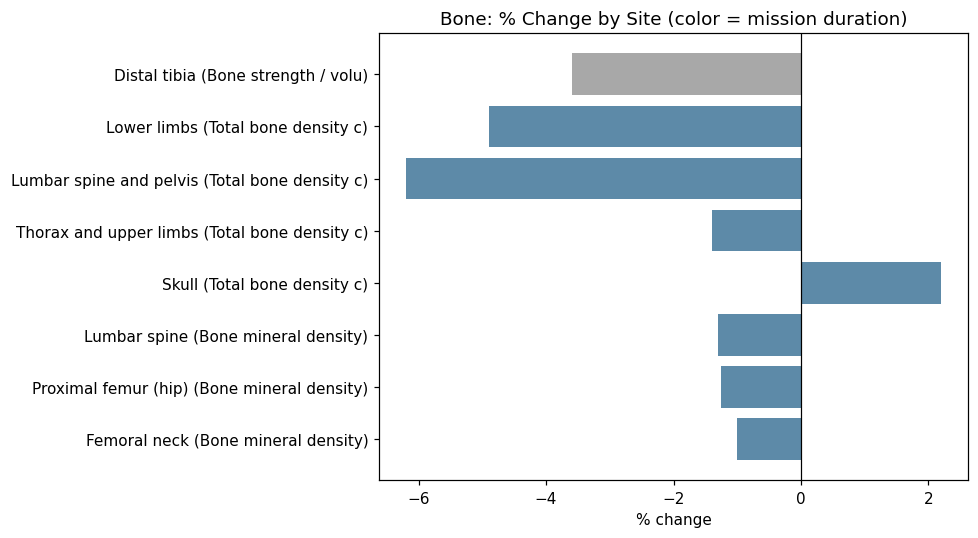

In [8]:
bone = physio[(physio['system']=='Bone') & (physio['metric_type'].isin(['percent_change_per_month','percent_change_total']))]

fig, ax = plt.subplots(figsize=(9,5))
colors = bone['mission_duration_category'].map({'Short':'#E8A87C','Long':'#5D8AA8','Mixed':'#A8A8A8'})
ax.barh(bone['body_site_or_context'] + ' (' + bone['measure'].str.slice(0,20) + ')', bone['value'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('% change')
ax.set_title('Bone: % Change by Site (color = mission duration)')
plt.tight_layout()
plt.savefig('../reports/figures/03_bone_changes.png')
plt.show()

**Finding**: bone loss is site-dependent, not uniform. Weight-bearing regions (lumbar spine/pelvis, lower limbs) lose the most (up to -6%), while the skull actually *gains* density (+2.2%) — consistent with the "use it or lose it" mechanical-loading theory of bone remodeling.

## 4. Muscle: % Change by Muscle Group, Short vs Long Duration

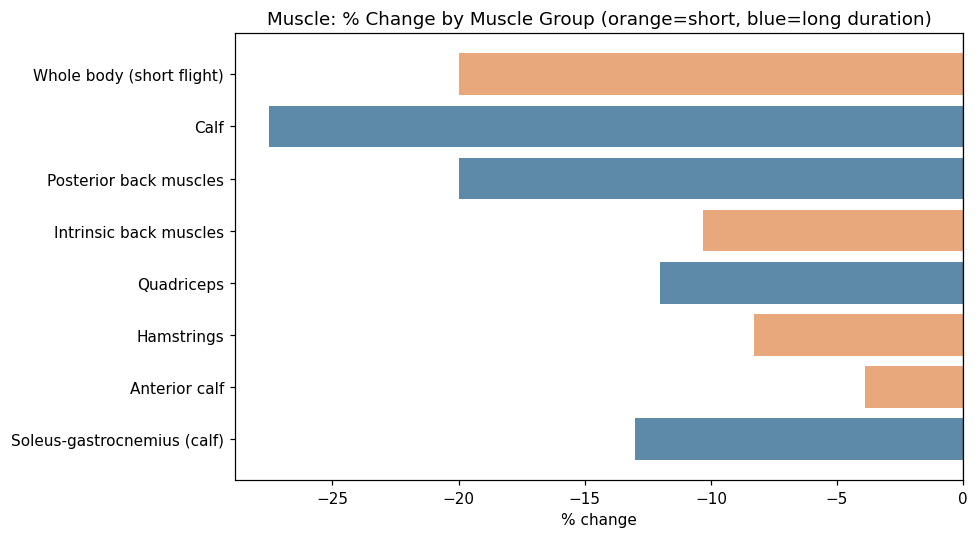

In [9]:
muscle = physio[physio['system']=='Muscle']

fig, ax = plt.subplots(figsize=(9,5))
colors = muscle['mission_duration_category'].map({'Short':'#E8A87C','Long':'#5D8AA8','Mixed':'#A8A8A8'})
ax.barh(muscle['body_site_or_context'], muscle['value'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('% change')
ax.set_title('Muscle: % Change by Muscle Group (orange=short, blue=long duration)')
plt.tight_layout()
plt.savefig('../reports/figures/04_muscle_changes.png')
plt.show()

**Finding**: for matching muscle groups (e.g. calf), long-duration losses are consistently larger than short-duration losses — a duration-dependence signal worth testing statistically in the next notebook.

## 5. Cardiovascular: Orthostatic Intolerance by Duration

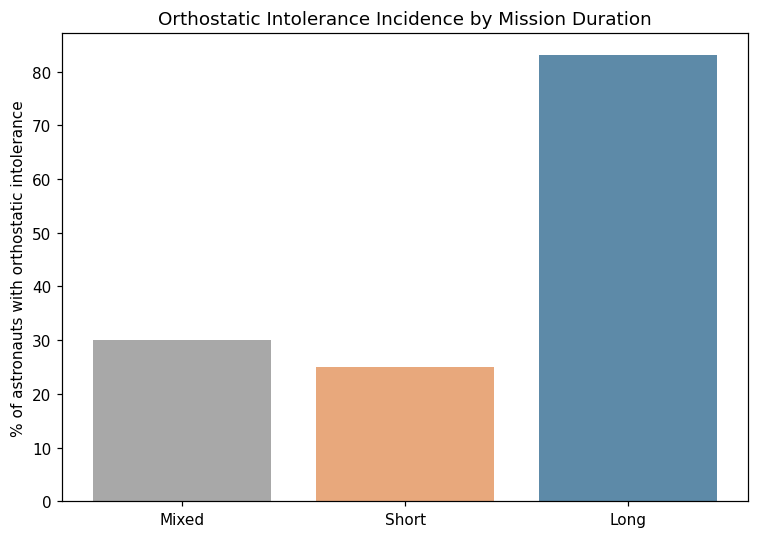

In [10]:
cardio_oi = physio[(physio['system']=='Cardiovascular') & (physio['measure']=='Orthostatic intolerance incidence')]

fig, ax = plt.subplots(figsize=(7,5))
colors = cardio_oi['mission_duration_category'].map({'Short':'#E8A87C','Long':'#5D8AA8','Mixed':'#A8A8A8'})
ax.bar(cardio_oi['mission_duration_category'], cardio_oi['value'], color=colors)
ax.set_ylabel('% of astronauts with orthostatic intolerance')
ax.set_title('Orthostatic Intolerance Incidence by Mission Duration')
plt.tight_layout()
plt.savefig('../reports/figures/06_cardio_oi.png')
plt.show()

**Finding**: orthostatic intolerance incidence jumps sharply with mission duration (~25-30% short vs. 83% long) — one of the strongest duration effects in the whole dataset.

## 6. Sleep: Hours by Context

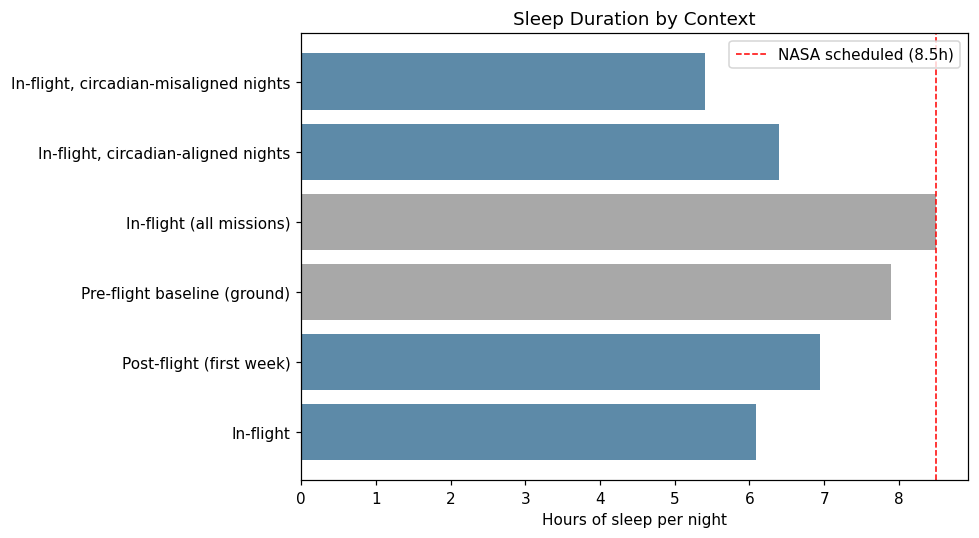

In [11]:
sleep = physio[(physio['system']=='Sleep') & (physio['metric_type']=='mean_hours')]

fig, ax = plt.subplots(figsize=(9,5))
colors = sleep['mission_duration_category'].map({'Short':'#E8A87C','Long':'#5D8AA8','Mixed':'#A8A8A8'})
ax.barh(sleep['body_site_or_context'], sleep['value'], color=colors)
ax.axvline(8.5, color='red', linestyle='--', linewidth=1, label='NASA scheduled (8.5h)')
ax.set_xlabel('Hours of sleep per night')
ax.set_title('Sleep Duration by Context')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/05_sleep_hours.png')
plt.show()

**Finding**: astronauts consistently sleep 2-3 hours less than NASA's 8.5h schedule, regardless of mission duration — this looks like an operational/environmental effect rather than a physiological-adaptation-over-time effect, unlike bone/muscle/cardiovascular.

## Next Steps (Notebook 02)
- Formal statistical comparison: short vs. long duration group differences (where multiple data points allow it)
- Correlation analysis between mission duration and effect magnitude
- Prepare final tidy tables for dashboard consumption